# Package overview

This python package is structured around 3 objects : <br>
A receiver : DAS <br>
A path : ray from Pykonal <br>
A source : Radiation pattern <br>
Each can be tuned to create a forward DAS amplitude model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import sys
import os
sys.path.append(os.path.abspath("../src"))
from fct_DAS_sensitivity import *

## DAS sensitivity

Create a DAS channel, It can take : <br>
<u>Orientation </u><br>
* azimuth ($\phi$) : Progress in trigonometric direction origin at the north <br>
==> positif angle rotate toward the west 
* dip ($\theta$) : Progress in antitrigonometric direction origin at the orizontal <br>
==> poitif angle dips the fiber up

<u>Gaugelength effect </u><br>
If thos parameters are given the model uses the gaugelength effect, otherwise, it will uses point strain rate equations. <br>
* Gaugelength : GL <br>
* wavelength : (m) <br>
* velocity : Wave velocity <br>

<u>DAS channel location</u> <br>
* latitude : in ° N <br>
* longitude : in ° E <br>
* depth: in km, positif values are going to the earth core <br>

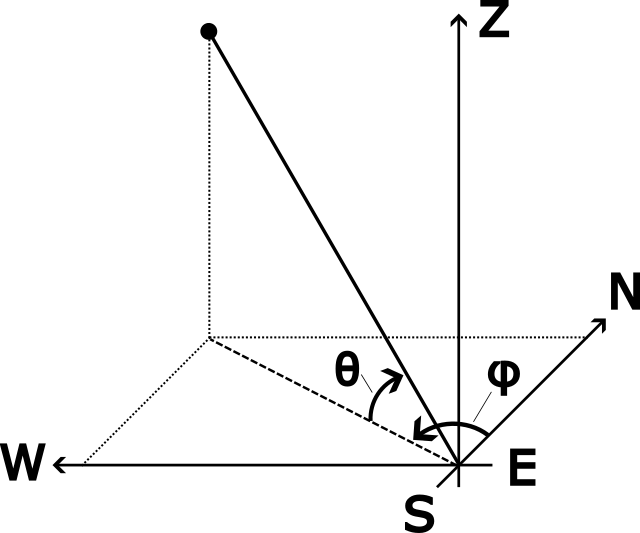

DAS sensor response (!!! can take Gauge length affect !!!)

In [2]:
das = DASSensor(
    azimuth=0,
    dip=0,
    gauge_length=None,
    wavelength=None,
    velocity=None, 
    latitude = None,
    longitude = None,
    depth = None,
)

When defining the DAS sensor response, you can play with the gaugelength to wavelength ratio and see the impact of the Gaugelength of the broadside sensitivity 

You can plot the orientation specific response of that channel in a polar plot 

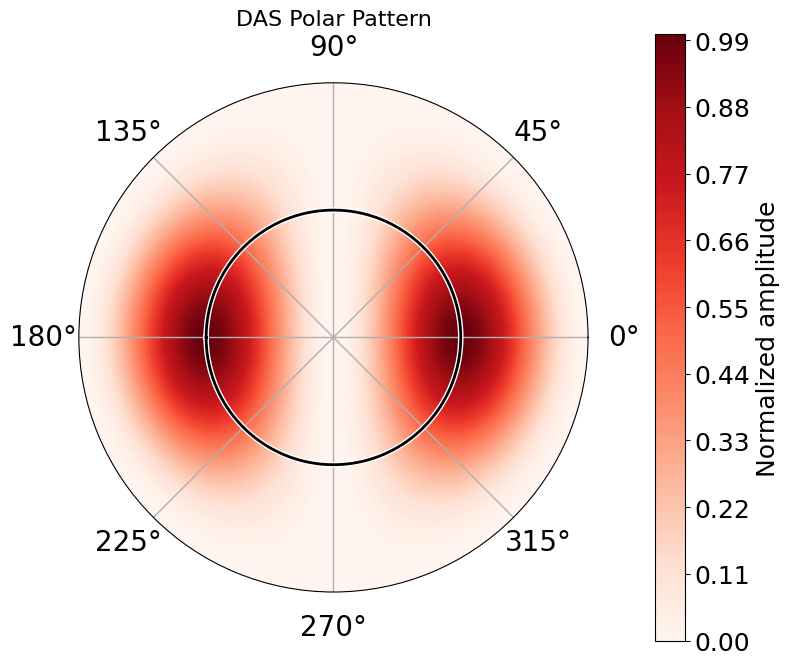

In [3]:
das.plot_polar_pattern('P')

This polar plot can also be viewed in a volume (Values normalised to max)

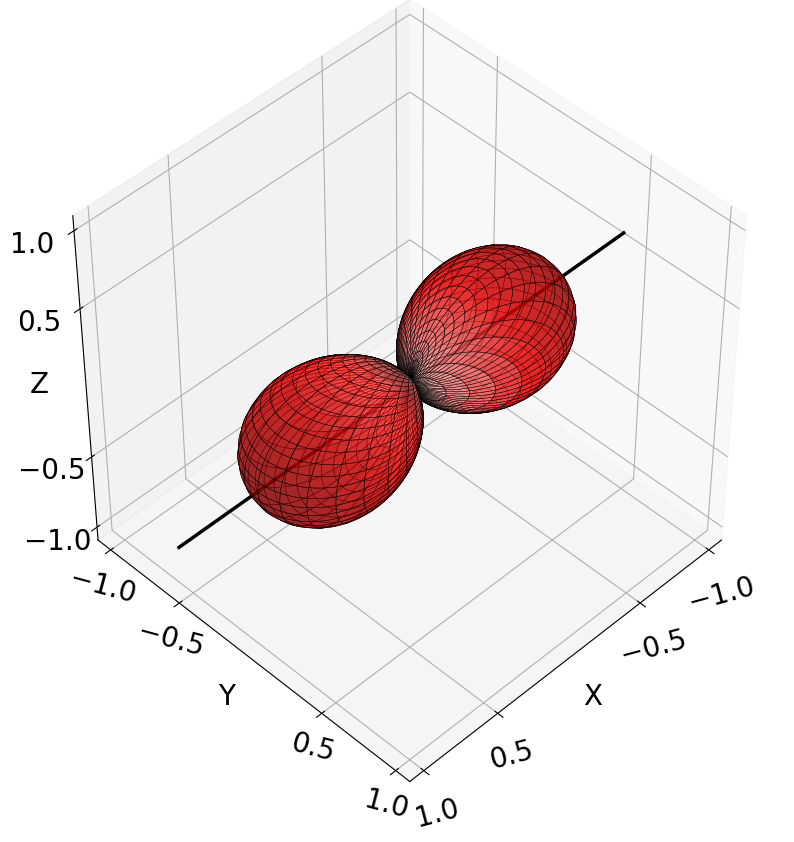

In [4]:
das.plot_3d_fiber_response('P')    

or directly get the sensitivity for a ray coming at e given dip and azimuth <br>
das.sensitivity(phase, azimuth, dip)

In [5]:
amplitude = das.sensitivity('P', 0, 0)
print(amplitude)

1.0


# Source description

#### Seismic source description

mt = IsotropicSource(1) # homogeneous distribution of energy arround the source <br>
mt = MomentTensor(1, 1, -2, 0, 0, 0) # (xx, yy, zz, xy, xz, yz) <br>
mt = SingleForce(1, 1, 0) # (x, y, z) <br>

In [6]:
# Locate your source in space 
loc = Location(50.85, 4.35, 100)
# Describe the energy inside 
mt = SingleForce(1, 0, 0) 
#Create the source object 
source = SeismicSource("Vibroseis", loc, mt)

### For a moment tensor only 

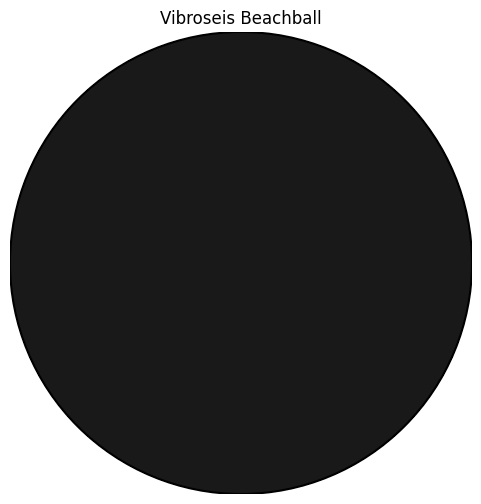

In [7]:
source.plot_beachball()

### Far all source type see the far field distribution of the energy 

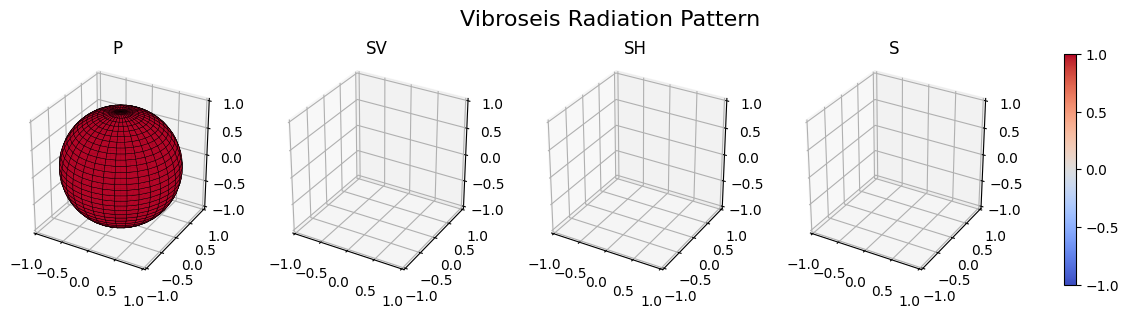

In [8]:
source.plot_radiation_pattern()

# Path

In [9]:
from pykonal.transformations import geo2sph, sph2geo

create a fake ray from ETHZ to ULB 

In [10]:

lats = np.linspace(47.3764,50.81193, 1000 ) # ° latitude (N)
lons = np.linspace(8.5473,4.38457, 1000 ) # ° longitude (E)
depth = np.linspace (1, 0, 1000) # km of depth

ray = np.array([lats, lons, depth])
ray = Ray(geo2sph(ray.T))

Ploting function to look at the ray 

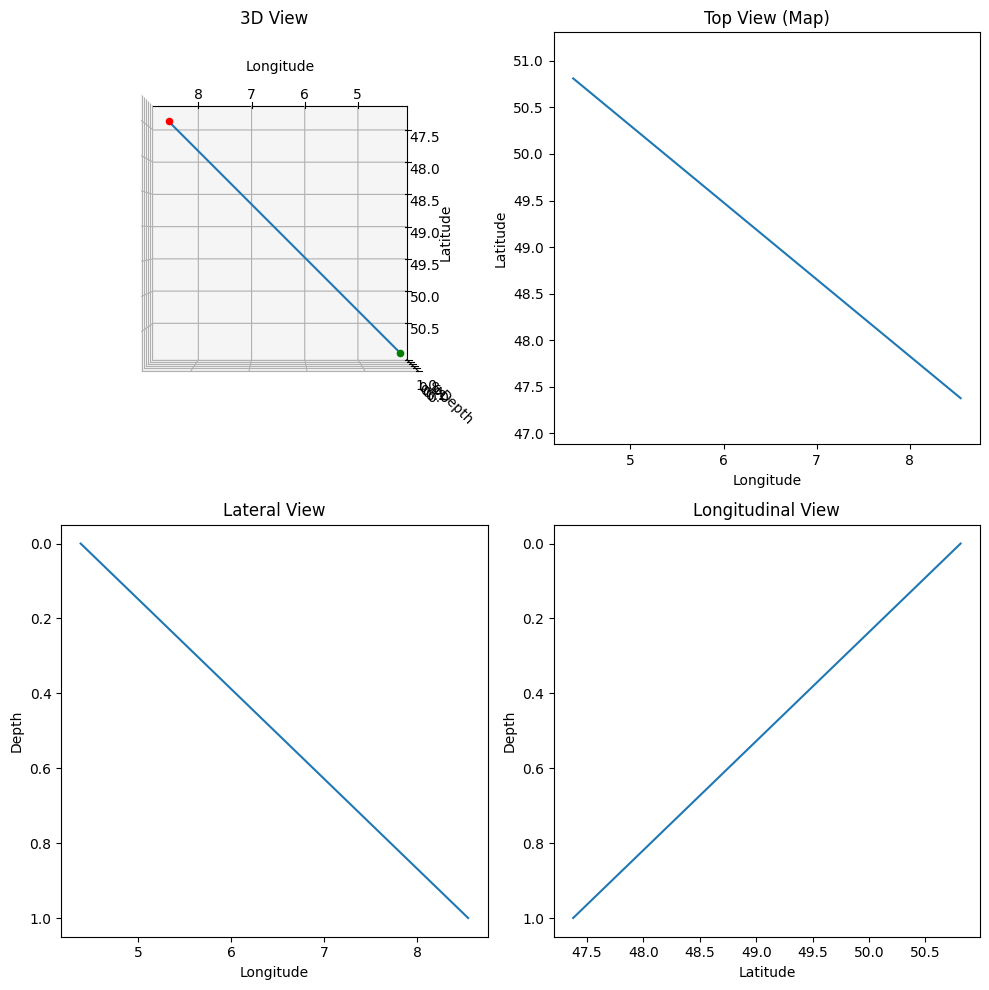

In [11]:
ray.plot_views()


Get the azimuth and the dip at the source and DAS using the n last nodes of the ray.

In [12]:
az_ray_DAS, dip_ray_DAS = ray.azimuth_and_dip('DAS', 50)
print('DAS azimuth, dip : '+str(az_ray_DAS)+' '+str(dip_ray_DAS)) 
az_ray_source, dip_ray_source = ray.azimuth_and_dip('source', 50)
print('Source azimuth, dip : '+str(az_ray_source)+' '+str(dip_ray_source)) 

DAS azimuth, dip : 228.887873155128 -0.09850855646168176
Source azimuth, dip : 48.97966431500703 0.0983275993994748
